# Single sample intracellular signalling network inference

In this notebook we showcase how to use the advanced CARNIVAL implementation available in CORNETO. This implementation extends the capabilities of the original CARNIVAL method by enabling advanced modelling and injection of knowledge for hypothesis generation. We will use a dataset consisting of 6 samples of hepatic stellate cells (HSC) where three of them were activated by the cytokine Transforming growth factor (TGF-β). 

We will show how to estimate Transcription Factor activities from gene expression data, following the [Decoupler tutorial](https://decoupler-py.readthedocs.io/en/latest/notebooks/bulk.html) for functional analysis. Then, we will use RIDDEN to estimate, in a similar fashion, receptor activities. Finally, we will use the CARNIVAL method available in CORNETO to infer a network from receptors to TFs, assuming that we don't really know which treatment was used.

Please keep in mind that CARNIVAL, as any other method, is designed to facilitate systematic exploration of intracellular signalling hypotheses by leveraging curated knowledge-base networks. It is **not** intended to produce a single, definitive solution.

- **Parameter Sensitivity**  
  Alterations in solver settings, threshold values, or choice of prior-knowledge networks can materially affect the inferred network.

- **Data Dependence**  
  The characteristics of your dataset—experimental design, sample size, preprocessing, and normalization—will directly influence model outputs.

- **Knowledge-Base Limitations**  
  Underlying pathway repositories may exhibit incomplete coverage and annotation biases.

Each network generated by CARNIVAL should be regarded as a potential, simplified hypothesis of the real signalling. Users are encouraged to compare multiple configurations and to validate the most promising models through further analysis and experimental validation.

> **NOTE:** This tutorial uses the new **Decoupler v2** version. We also use the **highs** free, open source solver, which has to be installed with `pip install highspy`

In [1]:
import gzip
import os
import shutil
import tempfile
import urllib.request
import pandas as pd

# https://decoupler-py.readthedocs.io
import decoupler as dc
import numpy as np

# https://omnipathdb.org/
import omnipath as op

# Pydeseq for differential expression analysis
from pydeseq2.dds import DefaultInference, DeseqDataSet
from pydeseq2.ds import DeseqStats

# https://corneto.org
import corneto as cn

<corneto-repository>/docs/tutorials/carnival/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-07-22 16:11:14 | [INFO] Downloading data from `https://omnipathdb.org/queries/enzsub?format=json`


2026-07-22 16:11:15 | [INFO] Downloading data from `https://omnipathdb.org/queries/interactions?format=json`


2026-07-22 16:11:15 | [INFO] Downloading data from `https://omnipathdb.org/queries/complexes?format=json`


2026-07-22 16:11:15 | [INFO] Downloading data from `https://omnipathdb.org/queries/annotations?format=json`


2026-07-22 16:11:15 | [INFO] Downloading data from `https://omnipathdb.org/queries/intercell?format=json`


2026-07-22 16:11:15 | [INFO] Downloading data from `https://omnipathdb.org/about?format=text`


In [2]:
dc.__version__

'2.0.6'

In [3]:
max_time = 300
seed = 0

In [4]:
# Load the dataset
adata = dc.ds.hsctgfb()
adata

AnnData object with n_obs × n_vars = 6 × 58674
    obs: 'condition', 'sample_id'

## Data preprocessing

We will use AnnData and PyDeseq2 to pre-process the data and compute differential expression between control and tretament

In [5]:
# Obtain genes that pass the thresholds
dc.pp.filter_by_expr(
    adata=adata,
    group="condition",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
adata

AnnData object with n_obs × n_vars = 6 × 19510
    obs: 'condition', 'sample_id'

In [6]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=adata,
    design_factors="condition",
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["condition", "treatment", "control"], inference=inference)

# Compute Wald test
stat_res.summary()

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/b4/gwkwsdb93sv11rtztqbm3l040000gn/T/ipykernel_38631/3092936879.py:3: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...


... done in 1.99 seconds.

Fitting dispersion trend curve...


... done in 0.52 seconds.

Fitting MAP dispersions...


... done in 1.10 seconds.

Fitting LFCs...


... done in 0.54 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition treatment vs control
                  baseMean  log2FoldChange     lfcSE       stat  \
RP11-347I19.8    88.877997       -0.207125  0.252557  -0.820110   
TMEM170B        103.807801       -0.276960  0.210575  -1.315260   
RP11-91P24.6    185.514929       -0.305848  0.180937  -1.690352   
SLC33A1        2559.269047        0.595912  0.085253   6.989890   
SNORA61          66.168502        0.746770  0.266470   2.802454   
...                    ...             ...       ...        ...   
RP11-75I2.3     771.828248        3.812419  0.128113  29.758231   
SLC25A24       3525.523888        0.651017  0.087599   7.431750   
BTN2A2          674.018191       -0.107905  0.106223  -1.015833   
RP11-101E3.5    194.084339        0.092515  0.181973   0.508402   
RP11-91I8.3      10.761886       -3.804532  0.920191  -4.134502   

                      pvalue           padj  
RP11-347I19.8   4.121536e-01   5.540987e-01  
TMEM170B        1.884227e-01   3.0

... done in 0.37 seconds.



In [7]:
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
RP11-347I19.8,88.877997,-0.207125,0.252557,-0.820110,4.121536e-01,5.540987e-01
TMEM170B,103.807801,-0.276960,0.210575,-1.315260,1.884227e-01,3.053908e-01
RP11-91P24.6,185.514929,-0.305848,0.180937,-1.690352,9.096068e-02,1.682470e-01
SLC33A1,2559.269047,0.595912,0.085253,6.989890,2.751015e-12,2.426415e-11
SNORA61,66.168502,0.746770,0.266470,2.802454,5.071542e-03,1.382697e-02
...,...,...,...,...,...,...
RP11-75I2.3,771.828248,3.812419,0.128113,29.758231,1.357073e-194,4.412748e-192
SLC25A24,3525.523888,0.651017,0.087599,7.431750,1.071704e-13,1.050701e-12
BTN2A2,674.018191,-0.107905,0.106223,-1.015833,3.097088e-01,4.492492e-01
RP11-101E3.5,194.084339,0.092515,0.181973,0.508402,6.111714e-01,7.290708e-01


In [8]:
data = results_df[["stat"]].T.rename(index={"stat": "treatment.vs.control"})
data

,RP11-347I19.8,TMEM170B,RP11-91P24.6,SLC33A1,SNORA61,THAP9-AS1,LIX1L,TTC8,WBSCR22,LPHN2,...,STARD4-AS1,ZNF845,NIPSNAP3B,ARL6IP5,MATN1-AS1,RP11-75I2.3,SLC25A24,BTN2A2,RP11-101E3.5,RP11-91I8.3
treatment.vs.control,-0.82011,-1.31526,-1.690352,6.98989,2.802454,1.531175,2.164055,-0.579835,-0.945628,-14.351065,...,14.484178,0.567176,-1.882852,-8.425175,-1.739571,29.758231,7.43175,-1.015833,0.508402,-4.134502


## Estimation of Transcription Factor activities with Deocupler and CollecTRI

In [9]:
# Retrieve CollecTRI gene regulatory network (through Omnipath).
# These are regulons that we will use for enrichment tests
# to infer TF activities
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [10]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# Filter by sign padj
msk = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, msk]

tf_acts

,APEX1,ARID1A,ARID4B,ARNT,ASXL1,ATF6,BARX2,BCL11A,BCL11B,BMAL2,...,TBX10,TCF21,TFAP2C,TP53,VEZF1,WWTR1,ZBTB33,ZEB2,ZNF804A,ZXDC
treatment.vs.control,-2.658269,-3.915338,-2.806407,3.170952,3.744263,2.705119,5.354716,2.647705,-4.201891,3.866736,...,-3.703038,6.159527,-2.57872,-3.618243,4.205744,-3.965664,3.235743,5.787311,3.363825,-2.733078


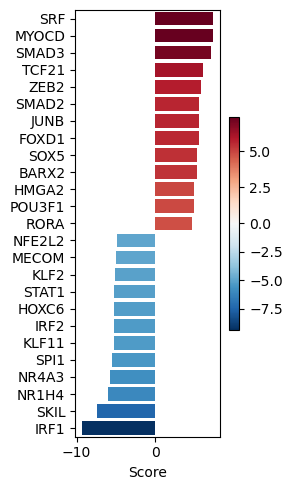

In [11]:
dc.pl.barplot(data=tf_acts, name="treatment.vs.control", top=25, figsize=(3, 5))

## Estimation of Receptor activities with RIDDEN

Now, we will use RIDDEN to estimate receptor activities. Here we know that the cells were treated with TGF-β, but we can assume that in general, this information might not be known. Let's use RIDDEN with Decoupler to find out, from gene expression alone, which receptors seem to be responsible of the downstream changes in gene expression.

> Barsi, S., Varga, E., Dimitrov, D., Saez-Rodriguez, J., Hunyady, L., & Szalai, B. (2025). RIDDEN: Data-driven inference of receptor activity from transcriptomic data. PLOS Computational Biology, 21(6), e1013188. https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1013188

In [12]:
# We obtain ligand-receptor interactions from Omnipath, and we keep only the receptors
# This is our list of a prior potential receptors from which we will infer the network
unique_receptors = set(op.interactions.LigRecExtra.get(genesymbols=True)["target_genesymbol"].values.tolist())
len(unique_receptors)

1201

In [13]:
# We load the RIDDEN matrix
df_ridden = pd.read_csv(
    "https://github.com/basvaat/RIDDEN_tool/raw/aa3c9d9880f135e95a079865ee20ebec984cf54d/ridden_model/ridden_model_matrix.csv",
    index_col=0,
)
df_ridden

,GNPDA1,CDH3,HDAC6,PARP2,MAMLD1,DNAJB6,SMC4,ABCC5,ABCB6,DNM1L,...,NCAPD2,PAN2,LPGAT1,KIF14,CDC25A,CDC25B,OXSR1,MVP,CDC42,DMTF1
CALCRL,-0.009687,-0.007085,0.161641,-0.088799,0.141184,0.206650,-0.077551,0.089438,0.052901,-0.097550,...,-0.029438,0.093616,-0.111194,0.055189,-0.267147,-0.132507,0.075775,0.206272,-0.086620,0.089023
IGF1R,0.186149,-0.019531,-0.226755,0.241395,-0.006143,-0.195346,-0.074546,-0.110967,-0.093491,0.144233,...,-0.092025,-0.249430,-0.090110,-0.148717,0.507459,-0.383608,0.080747,-0.325099,0.122792,-0.085241
TEK,-0.184470,0.103735,-0.178644,0.217038,-0.030282,-0.098075,0.457752,0.060260,0.101412,0.249132,...,-0.022321,-0.144688,-0.008170,0.418425,0.345027,0.257878,0.283288,-0.180285,0.361584,0.121627
GCGR,0.154128,-0.062489,0.193690,0.018437,0.037480,0.053541,0.120568,0.101133,0.055264,-0.231345,...,-0.074465,0.546507,-0.077048,0.118103,0.106227,-0.102328,-0.023940,-0.072013,0.026697,0.201512
AXL,-0.575718,0.078760,-0.014661,0.292999,0.070583,-0.012008,0.039746,0.006026,0.060853,0.119499,...,0.236579,-0.145577,-0.109871,0.046791,0.301887,-0.046162,-0.022249,-0.197795,0.319452,0.002319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LAT,-0.090900,-0.085613,-0.050680,0.071466,-0.020198,-0.005307,0.152670,0.605020,0.339265,-0.044672,...,0.077842,0.541145,-0.112621,0.378760,-0.020636,-0.188372,-0.031565,-0.447521,0.152605,0.233283
KIR3DL2,-0.113160,-0.078494,0.076545,-0.078937,0.243577,-0.189946,0.286184,0.039433,-0.174081,-0.109293,...,-0.148066,0.118362,0.199176,0.109609,0.091345,0.243448,0.109597,0.032553,0.254494,0.058646
ROR1,-0.090646,0.012197,-0.271497,-0.158861,0.256878,-0.078914,-0.364736,-0.012256,-0.192445,-0.670970,...,-0.005142,-0.096561,-0.262883,-0.399374,-0.109447,-0.239205,-0.257403,0.030898,0.098747,0.123366
AGER,0.020215,0.288864,0.214776,-0.022412,-0.038031,-0.152819,0.157402,0.367379,-0.038862,-0.294257,...,-0.198762,0.227099,0.167598,0.154016,0.059484,0.124841,0.020183,0.083234,0.290658,0.194672


In [14]:
df_receptor_de = data.loc[:, data.columns.intersection(df_ridden.columns)]
df_receptor_de

,CDC25B,CCNB2,ABCC5,NPDC1,AGL,GMNN,BLCAP,ISOC1,SLC35B1,PAK1,...,HMGCR,LAMA3,FAM57A,SSBP2,CXCL2,GTPBP8,TRIB3,HDAC2,LGALS8,BIRC5
treatment.vs.control,-8.391308,6.554248,-4.139615,-2.506713,0.299272,6.582295,-2.918605,-9.658493,3.163861,3.969934,...,7.125527,-3.862645,7.445228,-8.977077,-6.753168,-5.144084,2.988088,5.638864,-1.495224,6.237914


In [15]:
ridden_pkn = df_ridden.reset_index().melt(id_vars="index")
ridden_pkn.columns = ["source", "target", "weight"]
ridden_pkn

,source,target,weight
0,CALCRL,GNPDA1,-0.009687
1,IGF1R,GNPDA1,0.186149
2,TEK,GNPDA1,-0.184470
3,GCGR,GNPDA1,0.154128
4,AXL,GNPDA1,-0.575718
...,...,...,...
223957,LAT,DMTF1,0.233283
223958,KIR3DL2,DMTF1,0.058646
223959,ROR1,DMTF1,0.123366
223960,AGER,DMTF1,0.194672


In [16]:
# Number of receptors in RIDDEN
len(ridden_pkn.source.unique())

229

In [17]:
# Run receptor enrichment with ULM
pw_acts, pw_padj = dc.mt.ulm(data=df_receptor_de, net=ridden_pkn)

df_ridden_stats = pd.concat([pw_acts, pw_padj]).T
df_ridden_stats.columns = ["activity", "padj"]
df_ridden_stats

,activity,padj
ABCA1,-3.208177,0.005754
ACKR3,0.011038,0.992936
ACTR2,-0.732264,0.600567
ACVR1,1.325987,0.321247
ACVR1B,3.472131,0.002690
...,...,...
TRAF2,-3.728965,0.001258
TYRO3,-2.533851,0.033606
UTS2R,-4.147080,0.000334
VIPR1,1.316101,0.324505


<Axes: >

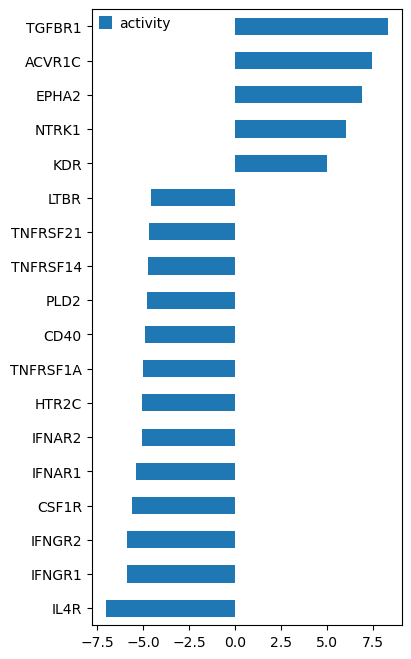

In [18]:
# We inferred from gene expression that TGFBR1 is the most active receptor
df_ridden_stats[df_ridden_stats.padj <= 0.0001][["activity"]].sort_values(by="activity", ascending=True).plot.barh(
    figsize=(4, 8)
)

## Inferring intracellular signalling network with CARNIVAL and CORNETO

CORNETO is a unified framework for knowledge-driven network inference. It includes a very flexible implementation of CARNIVAL that expands its original capabilities. We will see how to use it under different assumptions to extract a network from a prior knowledge network and a set of potential receptors + our estimated TFs

Installed version: v1.0.0rc1
Available backends: CVXPY v1.7.1
Default backend (corneto.opt): CVXPY
Installed solvers: CLARABEL, GUROBI, HIGHS, OSQP, SCIPY, SCS
Plot backend (default): auto -> graphviz
Available plot backends: graphviz v0.21; graphviz-wasm
Installed path: <corneto-repository>/docs/tutorials/carnival/.pixi/envs/default/lib/python3.11/site-packages/corneto
Repository: https://github.com/saezlab/corneto
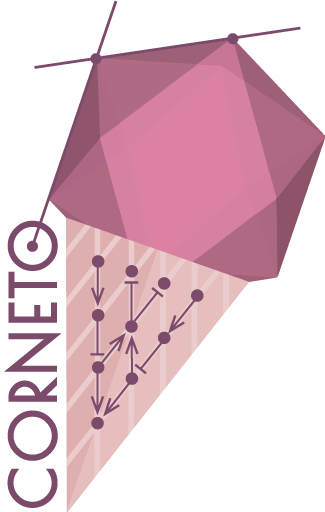

In [19]:
cn.info()

In [20]:
from corneto.methods import CarnivalFlow

CarnivalFlow.show_references()

- Pablo Rodriguez-Mier, Martin Garrido-Rodriguez, Attila Gabor, Julio Saez-Rodriguez. Unified knowledge-driven network inference from omics data. bioRxiv, pp. 10 (2024).
 - Anika Liu, Panuwat Trairatphisan, Enio Gjerga, Athanasios Didangelos, Jonathan Barratt, Julio Saez-Rodriguez. From expression footprints to causal pathways: contextualizing large signaling networks with CARNIVAL. NPJ systems biology and applications, Vol. 5, No. 1, pp. 40 (2019).

In [21]:
# We get only interactions from SIGNOR http://signor.uniroma2.it/
pkn = op.interactions.OmniPath.get(databases=["SIGNOR"], genesymbols=True)
pkn = pkn[pkn.consensus_direction == True]
pkn.head()

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped
0,Q13976,Q13507,PRKG1,TRPC3,True,False,True,True,False,True,9,HPRD:14983059;KEA:14983059;ProtMapper:14983059...,HPRD;HPRD_KEA;HPRD_MIMP;KEA;MIMP;PhosphoPoint;...,15,8,2,14983059;16331690
1,Q13976,Q9HCX4,PRKG1,TRPC7,True,True,False,True,True,False,3,SIGNOR:21402151;TRIP:21402151;iPTMnet:21402151,SIGNOR;TRIP;iPTMnet,3,3,1,21402151
2,Q13438,Q9HBA0,OS9,TRPV4,True,True,True,True,True,True,3,HPRD:17932042;SIGNOR:17932042;TRIP:17932042,HPRD;SIGNOR;TRIP,3,3,1,17932042
3,P18031,Q9H1D0,PTPN1,TRPV6,True,False,True,True,False,True,11,DEPOD:15894168;DEPOD:17197020;HPRD:15894168;In...,DEPOD;HPRD;IntAct;Lit-BM-17;SIGNOR;SPIKE_LC;TRIP,7,6,2,15894168;17197020
4,P63244,Q9BX84,RACK1,TRPM6,True,False,True,True,False,True,2,SIGNOR:18258429;TRIP:18258429,SIGNOR;TRIP,2,2,1,18258429


In [22]:
pkn["interaction"] = pkn["is_stimulation"].astype(int) - pkn["is_inhibition"].astype(int)
sel_pkn = pkn[["source_genesymbol", "interaction", "target_genesymbol"]]
sel_pkn

,source_genesymbol,interaction,target_genesymbol
0,PRKG1,-1,TRPC3
1,PRKG1,1,TRPC7
2,OS9,0,TRPV4
3,PTPN1,-1,TRPV6
4,RACK1,-1,TRPM6
...,...,...,...
61542,APC_PUF60_SIAH1_SKP1_TBL1X,-1,CTNNB1
61543,MAP2K6,1,MAPK10
61544,PRKAA1,1,TP53
61545,CNOT1_CNOT10_CNOT11_CNOT2_CNOT3_CNOT4_CNOT6_CN...,-1,NANOS2


In [23]:
# We create the CORNETO graph by importing the edges and interaction
from corneto.io import load_graph_from_sif_tuples

G = load_graph_from_sif_tuples([(r[0], r[1], r[2]) for _, r in sel_pkn.iterrows() if r[1] != 0])
G.shape

(5442, 60034)

In [24]:
# As measurements, we take the estimated TFs, we will filter out TFs with p-val > 0.001
significant_tfs = tf_acts[tf_padj <= 0.001].T.dropna().sort_values(by="treatment.vs.control", ascending=False)
significant_tfs

,treatment.vs.control
SRF,7.390611
MYOCD,7.342673
SMAD3,7.084429
TCF21,6.159527
ZEB2,5.787311
SMAD2,5.614428
JUNB,5.610473
FOXD1,5.566138
SOX5,5.385469
BARX2,5.354716


In [25]:
# We keep only the ones in the PKN graph
measurements = significant_tfs.loc[significant_tfs.index.intersection(G.V)].to_dict()["treatment.vs.control"]
measurements

{'SRF': 7.3906108743123164,
 'MYOCD': 7.342672817892572,
 'SMAD3': 7.0844294103820795,
 'ZEB2': 5.787311392244455,
 'SMAD2': 5.614427728369875,
 'JUNB': 5.610473028026834,
 'HMGA2': 4.918146140281221,
 'POU3F1': 4.903790337294035,
 'RORA': 4.748799034758163,
 'SMAD4': 4.4402600755156145,
 'MEF2A': 4.232877334898612,
 'FGF2': 4.207761616198675,
 'SMAD5': -4.004015430616565,
 'CIITA': -4.133309143328191,
 'NFKBIB': -4.154074213081593,
 'REL': -4.165033347663166,
 'PITX3': -4.198048894427097,
 'IRF3': -4.272799795168503,
 'PITX1': -4.340665200624415,
 'KLF8': -4.467109049496403,
 'DNMT3A': -4.622449958822471,
 'RELB': -4.681915557899264,
 'NFE2L2': -4.911003015915443,
 'MECOM': -4.942361740804518,
 'STAT1': -5.189258911506045,
 'HOXC6': -5.2154678064628905,
 'IRF2': -5.269444375678524,
 'KLF11': -5.269652535831714,
 'SPI1': -5.431022120705177,
 'NR4A3': -5.72350500604796,
 'NR1H4': -6.055602968386476,
 'SKIL': -7.433281684514384,
 'IRF1': -9.357500631318382}

In [26]:
"TGFBR1" in G.V

True

In [27]:
# Here we pass the receptors. We're going to use the top receptor inferred by RIDDEN
# (TGFBR1)
inputs = {"TGFBR1": 1}  # 1=up, -1=down
inputs

{'TGFBR1': 1}

In [28]:
# Create the dataset in standard format
carnival_data = dict()
for inp, v in inputs.items():
    carnival_data[inp] = dict(value=v, role="input", mapping="vertex")
for out, v in measurements.items():
    carnival_data[out] = dict(value=v, role="output", mapping="vertex")
data = cn.Data.from_cdict({"sample1": carnival_data})
data

Data(n_samples=1, n_feats=[34])

## CARNIVAL

We will use now the CARNIVAL, as implemented with CORNETO, with a penalty to regularize the solution. For hypothesis exploration, we can try different values and manually inspect the solutions. We are going to penalize also the selection of indirect rules, to simplify the solution. These rules are:
- A -> B in the PKN, and we observe B is downregulated, we explain it with downregulation of its upstream gene A
- A -| B in the PKN, and we observe B is upregulated, we explain it with downregulation of A

In [29]:
carnival = CarnivalFlow(lambda_reg=1.0, indirect_rule_penalty=10)
P = carnival.build(G, data)
P.expr

Unreachable vertices for sample: 0


{'_flow': _flow: Variable((3251,), _flow),
 'edge_activates': edge_activates: Variable((3251, 1), edge_activates, boolean=True),
 'edge_inhibits': edge_inhibits: Variable((3251, 1), edge_inhibits, boolean=True),
 'const0x689caa490bb1d38': const0x689caa490bb1d38: Constant(CONSTANT, NONNEGATIVE, (937, 3251)),
 '_dag_layer': _dag_layer: Variable((937, 1), _dag_layer),
 'const0x1f364c592f0a234': const0x1f364c592f0a234: Constant(CONSTANT, NONNEGATIVE, (937, 3251)),
 'flow': _flow: Variable((3251,), _flow),
 'vertex_value': Expression(AFFINE, UNKNOWN, (937, 1)),
 'vertex_activated': Expression(AFFINE, NONNEGATIVE, (937, 1)),
 'vertex_inhibited': Expression(AFFINE, NONNEGATIVE, (937, 1)),
 'edge_value': Expression(AFFINE, UNKNOWN, (3251, 1)),
 'edge_has_signal': Expression(AFFINE, NONNEGATIVE, (3251, 1)),
 'vertex_max_depth': _dag_layer: Variable((937, 1), _dag_layer)}

In [30]:
P.solve(solver="highs", max_seconds=60, verbosity=1);

(CVXPY) Jul 22 04:11:33 PM: Your problem has 10690 variables, 30607 constraints, and 1 parameters.


(CVXPY) Jul 22 04:11:33 PM: It is compliant with the following grammars: DCP, DQCP


(CVXPY) Jul 22 04:11:33 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.


(CVXPY) Jul 22 04:11:33 PM: Your problem is compiled with the CPP canonicalization backend.


(CVXPY) Jul 22 04:11:33 PM: Compiling problem (target solver=HIGHS).


...

(CVXPY) Jul 22 04:11:40 PM: Problem status: optimal


(CVXPY) Jul 22 04:11:40 PM: Optimal value: 9.298e+01


(CVXPY) Jul 22 04:11:40 PM: Compilation took 7.539e-02 seconds


(CVXPY) Jul 22 04:11:40 PM: Solver (including time spent in interface) took 6.124e+00 seconds



Restarting search from the root node
Model after restart has 1218 rows, 2727 cols (172 bin., 0 int., 0 impl., 2555 cont., 0 dom.fix.), and 7817 nonzeros

        20       0         0   0.00%   -30.4613484     -29.4613484        3.39%       17      0      0     18065     6.0s
 R      20       0         0   0.00%   -30.4613484     -30.32402383       0.45%       17      6      0     18569     6.0s

33.7% inactive integer columns, restarting
Model after restart has 999 rows, 2632 cols (105 bin., 0 int., 0 impl., 2527 cont., 0 dom.fix.), and 7136 nonzeros

        20       0         0   0.00%   -30.4613484     -30.32402383       0.45%        6      0      0     18569     6.0s
        20       0         0   0.00%   -30.4613484     -30.32402383       0.45%        6      4      3     18955     6.0s

10.5% inactive integer columns, restarting
Model after restart has 950 rows, 2611 cols (92 bin., 0 int., 0 impl., 2519 cont., 0 dom.fix.), and 6975 nonzeros

        20       0         0   0.00%  

In [31]:
# Error for sample is 0, meaning that all reachable TFs (from receptors) are correctly explained
for o in P.objectives:
    print(o.name, "->", o.value)

error_sample1_0 -> 64.98036838411093
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 28.0


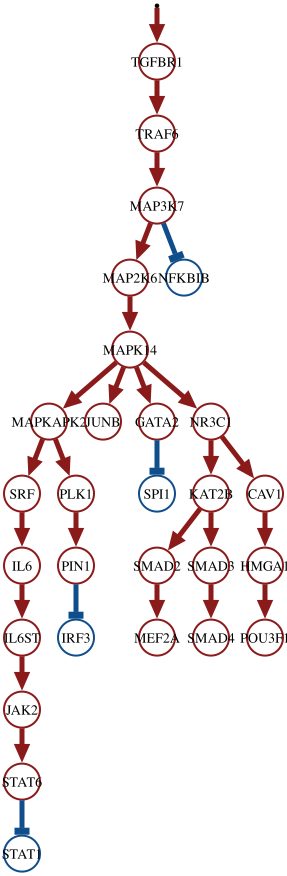

In [32]:
# We extract the selected edges
sol_edges = np.flatnonzero(np.abs(P.expr.edge_value.value) > 0.5)
carnival.processed_graph.plot_values(
    vertex_values=P.expr.vertex_value.value,
    edge_values=P.expr.edge_value.value,
    edge_indexes=sol_edges,
)

In [33]:
# Extracting the solution graph
G_sol = carnival.processed_graph.edge_subgraph(sol_edges)
G_sol.shape

(28, 28)

In [34]:
pd.DataFrame(
    P.expr.vertex_value.value,
    index=carnival.processed_graph.V,
    columns=["node_activity"],
)

,node_activity
P0DTC2_UBB,0.0
HRH1,0.0
ATM,0.0
TNFRSF1A,0.0
RAC1,0.0
...,...
PCBP2,0.0
MAF,0.0
MAP3K1,0.0
ARHGEF7,0.0


In [35]:
pd.DataFrame(P.expr.edge_value.value, index=carnival.processed_graph.E, columns=["edge_activity"])

,,edge_activity
(SMAD3),(MYOD1),0.0
(GRK2),(BDKRB2),0.0
(MAPK14),(MAPKAPK2),1.0
(DEPTOR_EEF1A1_MLST8_MTOR_PRR5_RICTOR),(FBXW8),0.0
(SLK),(MAP3K5),0.0
...,...,...
(REL),(),0.0
(MYOCD),(),0.0
(RORA),(),0.0
(IRF3),(),0.0


## Saving the processed dataset

In [36]:
cn.GraphData(G, data).save("data/carnival_transcriptomics_dataset")